In [ ]:
import pandas as pd
import zipfile
import os

# Αποσυμπίεση
zip_path = '/content/reduced_datasets.zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/reduced_data/')

# Προβολή αρχείων στον φάκελο
os.listdir('/content/reduced_data/')

os.listdir('/content/reduced_data/content/preterm_dataset_versions/')

# Φόρτωση τελικού αρχείου
df = pd.read_excel('/content/reduced_data/content/preterm_dataset_versions/reduced_preterm_dataset_1.xlsx')

# Προβολή δεδομένων
df.head()

,Maternal age,GA,BW centile,UtA doppler,b-hcg,DVP,MCA doppler,Papp-A,Height,UA doppler,...,Placental location_high posterior with anterior paraplacenta,Placental location_high right,Placental location_ligh anterior with posterior paraplacenta,Placental location_low anterior,Placental location_low posterior,Placental location_low posterior with anterior paraplacenta,Placental location_low right,Placental location_previa,Single umbilical artery_0,Single umbilical artery_1
0,33.000000,25.285714,16.129898,0.880,0.95,4.0,2.10,1.12,165.0,0.91,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,36.435616,32.571429,74.037300,0.675,1.30,3.6,1.87,0.50,175.0,0.79,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,42.000000,28.714286,71.680853,1.350,1.00,1.4,1.87,0.90,160.0,1.11,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,33.000000,29.285714,22.836726,0.640,1.13,4.1,2.02,1.12,163.0,1.08,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,39.454795,31.428571,81.205926,0.805,1.20,4.9,2.01,1.00,168.0,0.97,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
# Φόρτωση απαραίτητων βιβλιοθηκών
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import numpy as np

# Καθαρισμός δεδομένων
df['Preterm_birth'] = pd.to_numeric(df['Preterm_birth'], errors='coerce')
df_clean = df.dropna(subset=['Preterm_birth']).copy() # Αφαίρεση των γραμμών με τιμή NaN
df_clean = df_clean.drop(columns=['GA']) # Αφαίρεση γιατί επηρεάζει σημαντικά την πρόβλεψη
df_clean['Preterm_birth'] = df_clean['Preterm_birth'].astype(int)

X = df_clean.drop(columns=['Preterm_birth']) # Όλες οι μεταβλητές του dataset εκτός της Preterm_birth
y = df_clean['Preterm_birth'] # Η μεταβλητή στόχος (Preterm_birth)

# Διαχωρισμός σε Train(70%)/Test(30%) (πριν την εξισορρόπηση)
# random_state=42: αναπαραγωγιμότητα του ίδιου αποτελέσματος
# stratify=y: απαλοιφή ανισορροπιών στα δύο sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Εξισορρόπηση μόνο στο training set
sm = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = sm.fit_resample(X_train, y_train)

# 10-Fold Cross-Validation για internal validation
# eval_metric='logloss': μετρική εκπαίδευσης κατάλληλη για δυαδική αναζήτηση
# scale_pos_weight=1: καμία κατηγορία ('0' ή '1') δεν έχει πλεονέκτημα
xgb = XGBClassifier(eval_metric='logloss', random_state=42, scale_pos_weight=1)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'average_precision']
cv_results = cross_validate(xgb, X_train_balanced, y_train_balanced, cv=cv, scoring=scoring)
# Εκτύπωση του μέσου όρου κάθε μετρικής από τα 10 folds
for metric in scoring:
    print(f"{metric.upper()}: {np.mean(cv_results['test_' + metric]):.4f}")

# Τελική εκπαίδευση στο balanced training set και αξιολόγηση στο test set
xgb.fit(X_train_balanced, y_train_balanced)
y_pred = xgb.predict(X_test) # Προβλέψεις ανά κατηγορία ('0' ή '1')
y_proba = xgb.predict_proba(X_test)[:, 1] # Πιθανότητες για την κατηγορία '1' (πρόωρος τοκετός)

# Αποτελέσματα
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC AUC Score:", roc_auc_score(y_test, y_proba))
print("\nPR AUC Score:", average_precision_score(y_test, y_proba))

ACCURACY: 0.9656
PRECISION: 0.9531
RECALL: 0.9800
F1: 0.9662
ROC_AUC: 0.9939
AVERAGE_PRECISION: 0.9935

Confusion Matrix:
 [[185   8]
 [  3  44]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97       193
           1       0.85      0.94      0.89        47

    accuracy                           0.95       240
   macro avg       0.92      0.95      0.93       240
weighted avg       0.96      0.95      0.96       240


ROC AUC Score: 0.981479439973542

PR AUC Score: 0.9271487237935693


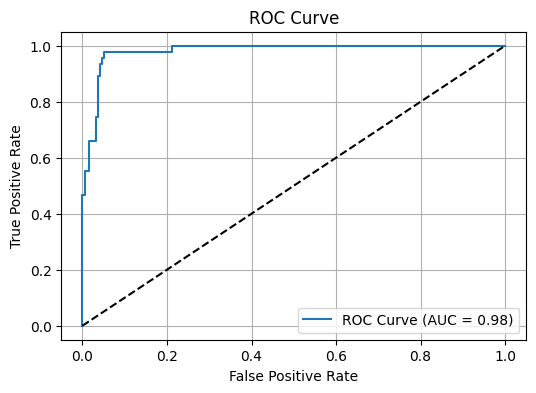

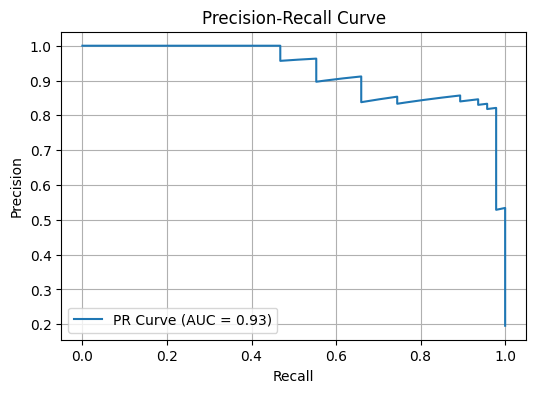

In [ ]:
# Φόρτωση απαραίτητων βιβλιοθηκών
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()

# PR Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Φόρτωση απαραίτητων βιβλιοθηκών
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Καθαρισμός δεδομένων
df['GA'] = pd.to_numeric(df['GA'], errors='coerce')
df_reg = df.dropna(subset=['GA']).copy()  # Αφαίρεση NaN από τη GA

X = df_reg.drop(columns=['GA', 'Preterm_birth']) # Όλες οι μεταβλητές εκτός των GA και Preterm_birth (επηρεάζει την πρόβλεψη)
y = df_reg['GA'] # Η μεταβλητή στόχος (GA - εβδομάδα τοκετού)

# Διαχωρισμός σε Train(70%)/Test(30%) (δεν χρειάζεται stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Ορισμός μοντέλου XGBoost
# n_estimators=100: πόσες διαδοχικές ενισχύσεις (boosting rounds) θα γίνουν (συνήθης χρήση αυτής της τιμής)
# verbosity=0: καταστέλλει την εμφάνιση μηνυμάτων κατά την εκπαίδευση
xgb_reg = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)

# 10-Fold Cross-Validation
cv = KFold(n_splits=10, shuffle=True, random_state=42)
scoring = ['r2', 'neg_mean_absolute_error', 'neg_mean_squared_error']

cv_results = cross_validate(xgb_reg, X_train, y_train, cv=cv, scoring=scoring)

# Εκπαίδευση στο πλήρες training set
xgb_reg.fit(X_train, y_train)

# Προβλέψεις στο test set
y_pred = xgb_reg.predict(X_test)

# Αξιολόγηση στο test set
print("\nEvaluation on Test Set:")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

Cross-Validation Results:
R²: 0.6522
MAE: 1.0083
MSE: 2.4168
RMSE: 1.5546

Evaluation on Test Set:
R² Score: 0.7299
MAE: 0.9993
MSE: 2.1389
RMSE: 1.4625


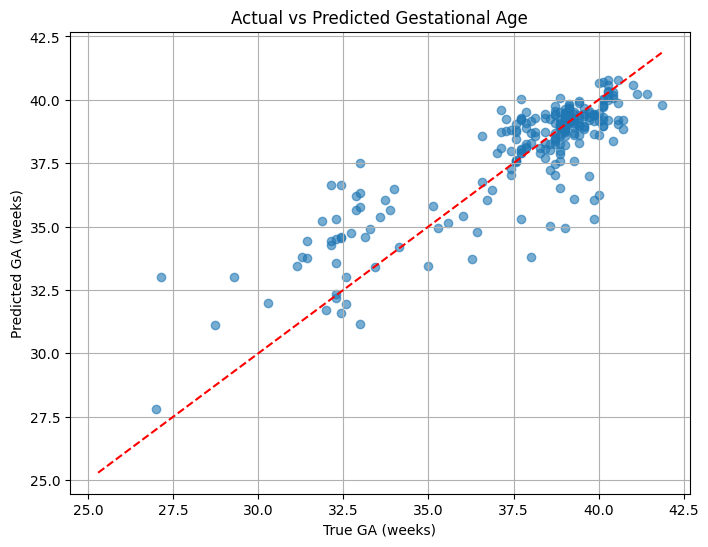

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("True GA (weeks)")
plt.ylabel("Predicted GA (weeks)")
plt.title("Actual vs Predicted Gestational Age")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Διαγώνια γραμμή
plt.grid(True)
plt.show()

In [ ]:
# Φόρτωση απαραίτητων βιβλιοθηκών
from sklearn.model_selection import GridSearchCV, train_test_split, KFold, cross_validate
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Καθαρισμός δεδομένων
df['GA'] = pd.to_numeric(df['GA'], errors='coerce')
df_reg = df.dropna(subset=['GA']).copy()  # Αφαίρεση NaN από τη GA

X = df_reg.drop(columns=['GA', 'Preterm_birth']) # Όλες οι μεταβλητές εκτός των GA και Preterm_birth (επηρεάζει την πρόβλεψη)
y = df_reg['GA'] # Η μεταβλητή στόχος (GA - εβδομάδα τοκετού)

# Διαχωρισμός σε Train(70%)/Test(30%) (δεν χρειάζεται stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Ορισμός του μοντέλου XGBRegressor
# verbosity=0: καταστέλλει την εμφάνιση μηνυμάτων κατά την εκπαίδευση
xgb_reg = XGBRegressor(random_state=42, verbosity=0)

# Ορισμός του πλέγματος παραμέτρων για τον Grid Search
# 'n_estimators': [50, 100, 200]: αριθμός δέντρων
# 'max_depth': [3, 5, 7]: μέγιστο βάθος κάθε δέντρου
# 'learning_rate': [0.01, 0.1, 0.2]: ρυθμός μάθησης
# 'subsample': [0.7, 1.0]: ποσοστό δειγμάτων που χρησιμοποιείται για κάθε δέντρο
# 'colsample_bytree': [0.7, 1.0]: ποσοστό χαρακτηριστικών που χρησιμοποιείται για κάθε δέντρο
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0]
}

# Ορισμός του GridSearchCV για εύρεση των καλύτερων παραμέτρων
# cv=10: 10-fold cross-validation
# n_jobs=-1: χρήση όλων των διαθέσιμων πυρήνων CPU
# verbose=1: επίπεδο λεπτομέρειας στην έξοδο
grid_search = GridSearchCV(
    estimator=xgb_reg,
    param_grid=param_grid,
    cv=10,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Εκπαίδευση του Grid Search στο training set
grid_search.fit(X_train, y_train)

# Εκτύπωση των βέλτιστων παραμέτρων που βρέθηκαν
print("Best parameters found:", grid_search.best_params_)

# Βελτιστοποιημένο μοντέλο
best_xgb = grid_search.best_estimator_

# Πρόβλεψη στο test set με την χρήση του βέλτιστου μοντέλου
y_pred = best_xgb.predict(X_test)

# Εκτύπωση μετρικών αξιολόγησης για το test set
print("\nEvaluation on Test Set (Optimized XGB Regressor):")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

Fitting 10 folds for each of 108 candidates, totalling 1080 fits
Best parameters found: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}

Evaluation on Test Set with best estimator:
R² Score: 0.7414
MAE: 0.9685
MSE: 2.0479
RMSE: 1.4310


In [ ]:
# Φόρτωση απαραίτητων βιβλιοθηκών
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Καθαρισμός δεδομένων
df['GA'] = pd.to_numeric(df['GA'], errors='coerce')
df_reg = df.dropna(subset=['GA']).copy()  # Αφαίρεση NaN από τη GA

# Στρογγυλοποίηση της GA στο ακέραιο μέρος
df_reg['GA'] = np.floor(df_reg['GA']).astype(int)

X = df_reg.drop(columns=['GA', 'Preterm_birth']) # Όλες οι μεταβλητές εκτός των GA και Preterm_birth (επηρεάζει την πρόβλεψη)
y = df_reg['GA'] # Η μεταβλητή στόχος (GA - εβδομάδα τοκετού)

# Διαχωρισμός σε Train(70%)/Test(30%) (δεν χρειάζεται stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Ορισμός μοντέλου XGBoost
# n_estimators=100: πόσες διαδοχικές ενισχύσεις (boosting rounds) θα γίνουν (συνήθης χρήση αυτής της τιμής)
# verbosity=0: καταστέλλει την εμφάνιση μηνυμάτων κατά την εκπαίδευση
xgb_reg = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)

# 10-Fold Cross-Validation
cv = KFold(n_splits=10, shuffle=True, random_state=42)
scoring = ['r2', 'neg_mean_absolute_error', 'neg_mean_squared_error']

cv_results = cross_validate(xgb_reg, X_train, y_train, cv=cv, scoring=scoring)

# Εκπαίδευση στο πλήρες training set
xgb_reg.fit(X_train, y_train)

# Προβλέψεις και στρογγυλοποίηση στο ακέραιο για αξιολόγηση του test set
y_pred = xgb_reg.predict(X_test)
y_pred_rounded = np.round(y_pred).astype(int)

# Αξιολόγηση στο test set
print("\nEvaluation on Test Set (Rounded Predictions):")
print(f"R² Score: {r2_score(y_test, y_pred_rounded):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rounded):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_rounded):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rounded)):.4f}")


Evaluation on Test Set (Rounded Predictions):
R² Score: 0.7056
MAE: 0.9542
MSE: 2.3208
RMSE: 1.5234


In [ ]:
# Φόρτωση απαραίτητων βιβλιοθηκών
from sklearn.model_selection import GridSearchCV, train_test_split, KFold, cross_validate
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Καθαρισμός δεδομένων
df['GA'] = pd.to_numeric(df['GA'], errors='coerce')
df_reg = df.dropna(subset=['GA']).copy()  # Αφαίρεση NaN από τη GA

# Στρογγυλοποίηση της GA στο ακέραιο μέρος
df_reg['GA'] = np.floor(df_reg['GA']).astype(int)

X = df_reg.drop(columns=['GA', 'Preterm_birth']) # Όλες οι μεταβλητές εκτός των GA και Preterm_birth (επηρεάζει την πρόβλεψη)
y = df_reg['GA'] # Η μεταβλητή στόχος (GA - εβδομάδα τοκετού)

# Διαχωρισμός σε Train(70%)/Test(30%) (δεν χρειάζεται stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Ορισμός του μοντέλου XGBRegressor
# verbosity=0: καταστέλλει την εμφάνιση μηνυμάτων κατά την εκπαίδευση
xgb_reg = XGBRegressor(random_state=42, verbosity=0)

# Ορισμός του πλέγματος παραμέτρων για τον Grid Search
# 'n_estimators': [50, 100, 200]: αριθμός δέντρων
# 'max_depth': [3, 5, 7]: μέγιστο βάθος κάθε δέντρου
# 'learning_rate': [0.01, 0.1, 0.2]: ρυθμός μάθησης
# 'subsample': [0.7, 1.0]: ποσοστό δειγμάτων που χρησιμοποιείται για κάθε δέντρο
# 'colsample_bytree': [0.7, 1.0]: ποσοστό χαρακτηριστικών που χρησιμοποιείται για κάθε δέντρο
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0]
}

# Ορισμός του GridSearchCV με Ridge Regression για εύρεση των καλύτερων παραμέτρων
# cv=10: 10-fold cross-validation
# n_jobs=-1: χρήση όλων των διαθέσιμων πυρήνων CPU
# verbose=1: επίπεδο λεπτομέρειας στην έξοδο
grid_search = GridSearchCV(
    estimator=xgb_reg,
    param_grid=param_grid,
    cv=10,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Εκπαίδευση του Grid Search στο training set
grid_search.fit(X_train, y_train)

# Εκτύπωση των βέλτιστων παραμέτρων που βρέθηκαν
print("Best parameters found:", grid_search.best_params_)

# Βελτιστοποιημένο μοντέλο
best_xgb = grid_search.best_estimator_

# Πρόβλεψη στο test set με την χρήση του βέλτιστου μοντέλου
y_pred = best_xgb.predict(X_test)
y_pred_best_rounded = np.round(y_pred).astype(int)

# Εκτύπωση μετρικών αξιολόγησης για το test set
print("\nEvaluation on Test Set (Best GridSearch Model):")
print(f"R² Score: {r2_score(y_test, y_pred_best_rounded):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_best_rounded):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_best_rounded):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best_rounded)):.4f}")

Fitting 10 folds for each of 108 candidates, totalling 1080 fits
Best parameters found: {'colsample_bytree': 0.7, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}

Evaluation on Test Set (Best GridSearch Model):
R² Score: 0.7458
MAE: 0.8708
MSE: 2.0042
RMSE: 1.4157


In [ ]:
# Φόρτωση απαραίτητων βιβλιοθηκών
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import numpy as np

# Δημιουργία κατηγορικής μεταβλητής με βάση την GA
def month_birth(ga):
    if ga <= 35:
        return '6ος-8ος μήνας'
    elif ga <= 40:
        return '9ος μήνας'
    else:
        return '10ος μήνας'

# Καθαρισμός δεδομένων
df['GA'] = pd.to_numeric(df['GA'], errors='coerce')
df_clean = df.dropna(subset=['GA']).copy()
# Εφαρμογή της συνάρτησης month_birth σε κάθε GA και αποθήκευση του αποτελέσματος στη νέα στήλη 'month_birth'
df_clean['month_birth'] = df_clean['GA'].apply(month_birth)

X = df_clean.drop(columns=['GA', 'month_birth', 'Preterm_birth']) # Όλες οι μεταβλητές του dataset εκτός των GA, month_birth, Preterm_birth
y = df_clean['month_birth'] # Η μεταβλητή στόχος (month_birth)

# Ετικετοποίηση της κατηγορικής μεταβλητής y (Label Encoding)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Διαχωρισμός σε Train(70%)/Test(30%) (πριν την εξισορρόπηση)
# random_state=42: αναπαραγωγιμότητα του ίδιου αποτελέσματος
# stratify=y: απαλοιφή ανισορροπιών στα δύο sets
X_train, X_test, y_train_encoded, y_test_encoded = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

# Εξισορρόπηση μόνο στο training set
sm = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = sm.fit_resample(X_train, y_train_encoded)

# 10-Fold Cross-Validation για internal validation
# eval_metric='logloss': μετρική εκπαίδευσης κατάλληλη για δυαδική αναζήτηση
xgb = XGBClassifier(eval_metric='logloss', random_state=42)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
cv_results = cross_validate(xgb, X_train_balanced, y_train_balanced, cv=cv, scoring=scoring)
# Εκτύπωση του μέσου όρου κάθε μετρικής από τα 10 folds
for metric in scoring:
    print(f"{metric.upper()}: {np.mean(cv_results['test_' + metric]):.4f}")

# Τελική εκπαίδευση στο balanced training set και αξιολόγηση στο test set
xgb.fit(X_train_balanced, y_train_balanced)
y_pred_encoded = xgb.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)
y_test = le.inverse_transform(y_test_encoded)

# Αποτελέσματα
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

ACCURACY: 0.9346
PRECISION_MACRO: 0.9357
RECALL_MACRO: 0.9347
F1_MACRO: 0.9339

Confusion Matrix:
 [[ 30   2   5]
 [  0  36   3]
 [ 12  12 140]]

Classification Report:
                precision    recall  f1-score   support

   10ος μήνας       0.71      0.81      0.76        37
6ος-8ος μήνας       0.72      0.92      0.81        39
    9ος μήνας       0.95      0.85      0.90       164

     accuracy                           0.86       240
    macro avg       0.79      0.86      0.82       240
 weighted avg       0.87      0.86      0.86       240



In [ ]:
# Φόρτωση απαραίτητων βιβλιοθηκών
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import numpy as np

# Δημιουργία κατηγορικής μεταβλητής με βάση την GA
def month_birth(ga):
    if ga <= 35:
        return '6ος-8ος μήνας'
    elif ga <= 40:
        return '9ος μήνας'
    else:
        return '10ος μήνας'

# Καθαρισμός δεδομένων
df['GA'] = pd.to_numeric(df['GA'], errors='coerce')
df_clean = df.dropna(subset=['GA']).copy()
# Εφαρμογή της συνάρτησης month_birth σε κάθε GA και αποθήκευση του αποτελέσματος στη νέα στήλη 'month_birth'
df_clean['month_birth'] = df_clean['GA'].apply(month_birth)

X = df_clean.drop(columns=['GA', 'month_birth', 'Preterm_birth']) # Όλες οι μεταβλητές του dataset εκτός των GA, month_birth, Preterm_birth
y = df_clean['month_birth'] # Η μεταβλητή στόχος (month_birth)

# Ετικετοποίηση της κατηγορικής μεταβλητής y (Label Encoding)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Διαχωρισμός σε Train(70%)/Test(30%) (πριν την εξισορρόπηση)
# random_state=42: αναπαραγωγιμότητα του ίδιου αποτελέσματος
# stratify=y: απαλοιφή ανισορροπιών στα δύο sets
X_train, X_test, y_train_encoded, y_test_encoded = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

# Εξισορρόπηση μόνο στο training set
sm = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = sm.fit_resample(X_train, y_train_encoded)

# Ορισμός του μοντέλου XGBClassifier
# verbosity=0: καταστέλλει την εμφάνιση μηνυμάτων κατά την εκπαίδευση
xgb= XGBClassifier(random_state=42, verbosity=0)

# Ορισμός του πλέγματος παραμέτρων για τον Grid Search
# 'n_estimators': [50, 100, 200]: αριθμός δέντρων
# 'max_depth': [3, 5, 7]: μέγιστο βάθος κάθε δέντρου
# 'learning_rate': [0.01, 0.1, 0.2]: ρυθμός μάθησης
# 'subsample': [0.7, 1.0]: ποσοστό δειγμάτων που χρησιμοποιείται για κάθε δέντρο
# 'colsample_bytree': [0.7, 1.0]: ποσοστό χαρακτηριστικών που χρησιμοποιείται για κάθε δέντρο
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0]
}

# Ορισμός του GridSearchCV για εύρεση των καλύτερων παραμέτρων
# cv=10: 10-fold cross-validation
# n_jobs=-1: χρήση όλων των διαθέσιμων πυρήνων CPU
# verbose=1: επίπεδο λεπτομέρειας στην έξοδο
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=10,
    scoring='recall_macro',
    n_jobs=-1,
    verbose=1
)

# Εκπαίδευση του Grid Search στο training set
grid_search.fit(X_train_balanced, y_train_balanced)

# Εκτύπωση των βέλτιστων παραμέτρων που βρέθηκαν
print("Best Parameters:", grid_search.best_params_)

# Βελτιστοποιημένο μοντέλο
best_model = grid_search.best_estimator_

# Πρόβλεψη στο test set με την χρήση του βέλτιστου μοντέλου
y_pred = best_model.predict(X_test)
y_pred_encoded = best_model.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)
y_test = le.inverse_transform(y_test_encoded)

# Αποτελέσματα
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Fitting 10 folds for each of 108 candidates, totalling 1080 fits
Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.7}

Confusion Matrix:
 [[ 28   2   7]
 [  0  36   3]
 [ 15  13 136]]

Classification Report:
                precision    recall  f1-score   support

   10ος μήνας       0.65      0.76      0.70        37
6ος-8ος μήνας       0.71      0.92      0.80        39
    9ος μήνας       0.93      0.83      0.88       164

     accuracy                           0.83       240
    macro avg       0.76      0.84      0.79       240
 weighted avg       0.85      0.83      0.84       240



In [ ]:
# Φόρτωση απαραίτητων βιβλιοθηκών
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import numpy as np

# Δημιουργία κατηγορικής μεταβλητής με βάση την GA
def ga_bin_2weeks(ga):
    # Στρογγυλοποίηση προς τα κάτω και μετατροπή σε integer
    week = int(np.floor(ga))

    if 25 <= week <= 30:
        return '25-30'
    elif 31 <= week <= 32:
        return '31-32'
    elif 33 <= week <= 34:
        return '33-34'
    elif 35 <= week <= 36:
        return '35-36'
    elif 37 <= week <= 38:
        return '37-38'
    elif 39 <= week <= 40:
        return '39-40'
    elif 41 <= week <= 42:
        return '41-42'
    else:
        return 'εκτός ορίων'

# Καθαρισμός δεδομένων
df['GA'] = pd.to_numeric(df['GA'], errors='coerce')
df_clean = df.dropna(subset=['GA']).copy()
# Εφαρμογή της συνάρτησης ga_bin σε κάθε GA και αποθήκευση του αποτελέσματος στη νέα στήλη 'ga_bin'
df_clean['ga_bin'] = df_clean['GA'].apply(ga_bin_2weeks)

X = df_clean.drop(columns=['GA', 'ga_bin', 'Preterm_birth']) # Όλες οι μεταβλητές του dataset εκτός των GA, ga_bin, Preterm_birth
y = df_clean['ga_bin'] # Η μεταβλητή στόχος (ga_bin)

# Ετικετοποίηση της κατηγορικής μεταβλητής y (Label Encoding)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Διαχωρισμός σε Train(70%)/Test(30%) (πριν την εξισορρόπηση)
# random_state=42: αναπαραγωγιμότητα του ίδιου αποτελέσματος
# stratify=y: απαλοιφή ανισορροπιών στα δύο sets
X_train, X_test, y_train_encoded, y_test_encoded = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

# Εξισορρόπηση μόνο στο training set
sm = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = sm.fit_resample(X_train, y_train_encoded)

# 10-Fold Cross-Validation για internal validation
# eval_metric='logloss': μετρική εκπαίδευσης κατάλληλη για δυαδική αναζήτηση
xgb = XGBClassifier(eval_metric='logloss', random_state=42)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
cv_results = cross_validate(xgb, X_train_balanced, y_train_balanced, cv=cv, scoring=scoring)
# Εκτύπωση του μέσου όρου κάθε μετρικής από τα 10 folds
for metric in scoring:
    print(f"{metric.upper()}: {np.mean(cv_results['test_' + metric]):.4f}")

# Τελική εκπαίδευση στο balanced training set και αξιολόγηση στο test set
xgb.fit(X_train_balanced, y_train_balanced)
y_pred_encoded = xgb.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)
y_test = le.inverse_transform(y_test_encoded)

# Αποτελέσματα
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

ACCURACY: 0.9508
PRECISION_MACRO: 0.9512
RECALL_MACRO: 0.9508
F1_MACRO: 0.9500

Confusion Matrix:
 [[ 2  0  1  0  0  0  0]
 [ 0 20  2  1  1  0  0]
 [ 0  5  3  2  1  0  0]
 [ 1  1  2  1  3  1  0]
 [ 0  1  3  0 59 11  0]
 [ 0  3  0  0 13 98  1]
 [ 0  0  0  0  0  4  0]]

Classification Report:
               precision    recall  f1-score   support

       25-30       0.67      0.67      0.67         3
       31-32       0.67      0.83      0.74        24
       33-34       0.27      0.27      0.27        11
       35-36       0.25      0.11      0.15         9
       37-38       0.77      0.80      0.78        74
       39-40       0.86      0.85      0.86       115
       41-42       0.00      0.00      0.00         4

    accuracy                           0.76       240
   macro avg       0.50      0.50      0.50       240
weighted avg       0.75      0.76      0.75       240



In [ ]:
# Φόρτωση απαραίτητων βιβλιοθηκών
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import numpy as np

# Δημιουργία κατηγορικής μεταβλητής με βάση την GA
def ga_bin_2weeks(ga):
    # Στρογγυλοποίηση προς τα κάτω και μετατροπή σε integer
    week = int(np.floor(ga))

    if 25 <= week <= 30:
        return '25-30'
    elif 31 <= week <= 32:
        return '31-32'
    elif 33 <= week <= 34:
        return '33-34'
    elif 35 <= week <= 36:
        return '35-36'
    elif 37 <= week <= 38:
        return '37-38'
    elif 39 <= week <= 40:
        return '39-40'
    elif 41 <= week <= 42:
        return '41-42'
    else:
        return 'εκτός ορίων'

# Καθαρισμός δεδομένων
df['GA'] = pd.to_numeric(df['GA'], errors='coerce')
df_clean = df.dropna(subset=['GA']).copy()
# Εφαρμογή της συνάρτησης ga_bin σε κάθε GA και αποθήκευση του αποτελέσματος στη νέα στήλη 'ga_bin'
df_clean['ga_bin'] = df_clean['GA'].apply(ga_bin_2weeks)

X = df_clean.drop(columns=['GA', 'ga_bin', 'Preterm_birth']) # Όλες οι μεταβλητές του dataset εκτός των GA, ga_bin, Preterm_birth
y = df_clean['ga_bin'] # Η μεταβλητή στόχος (ga_bin)

# Ετικετοποίηση της κατηγορικής μεταβλητής y (Label Encoding)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Διαχωρισμός σε Train(70%)/Test(30%) (πριν την εξισορρόπηση)
# random_state=42: αναπαραγωγιμότητα του ίδιου αποτελέσματος
# stratify=y: απαλοιφή ανισορροπιών στα δύο sets
X_train, X_test, y_train_encoded, y_test_encoded = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

# Εξισορρόπηση μόνο στο training set
sm = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = sm.fit_resample(X_train, y_train_encoded)

# Ορισμός του μοντέλου XGBClassifier
# verbosity=0: καταστέλλει την εμφάνιση μηνυμάτων κατά την εκπαίδευση
xgb= XGBClassifier(random_state=42, verbosity=0)

# Ορισμός του πλέγματος παραμέτρων για τον Grid Search
# 'n_estimators': [50, 100, 200]: αριθμός δέντρων
# 'max_depth': [3, 5, 7]: μέγιστο βάθος κάθε δέντρου
# 'learning_rate': [0.01, 0.1, 0.2]: ρυθμός μάθησης
# 'subsample': [0.7, 1.0]: ποσοστό δειγμάτων που χρησιμοποιείται για κάθε δέντρο
# 'colsample_bytree': [0.7, 1.0]: ποσοστό χαρακτηριστικών που χρησιμοποιείται για κάθε δέντρο
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0]
}

# Ορισμός του GridSearchCV για εύρεση των καλύτερων παραμέτρων
# cv=10: 10-fold cross-validation
# n_jobs=-1: χρήση όλων των διαθέσιμων πυρήνων CPU
# verbose=1: επίπεδο λεπτομέρειας στην έξοδο
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=10,
    scoring='recall_macro',
    n_jobs=-1,
    verbose=1
)

# Εκπαίδευση του Grid Search στο training set
grid_search.fit(X_train_balanced, y_train_balanced)

# Εκτύπωση των βέλτιστων παραμέτρων που βρέθηκαν
print("Best Parameters:", grid_search.best_params_)

# Βελτιστοποιημένο μοντέλο
best_model = grid_search.best_estimator_

# Πρόβλεψη στο test set με την χρήση του βέλτιστου μοντέλου
y_pred = best_model.predict(X_test)
y_pred_encoded = best_model.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)
y_test = le.inverse_transform(y_test_encoded)

# Αποτελέσματα
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Fitting 10 folds for each of 108 candidates, totalling 1080 fits
Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 1.0}

Confusion Matrix:
 [[ 2  0  0  0  1  0  0]
 [ 0 20  3  0  0  1  0]
 [ 0  6  3  2  0  0  0]
 [ 1  1  2  0  3  2  0]
 [ 0  1  3  0 58 12  0]
 [ 0  4  0  0 13 98  0]
 [ 0  0  0  0  0  4  0]]

Classification Report:
               precision    recall  f1-score   support

       25-30       0.67      0.67      0.67         3
       31-32       0.62      0.83      0.71        24
       33-34       0.27      0.27      0.27        11
       35-36       0.00      0.00      0.00         9
       37-38       0.77      0.78      0.78        74
       39-40       0.84      0.85      0.84       115
       41-42       0.00      0.00      0.00         4

    accuracy                           0.75       240
   macro avg       0.45      0.49      0.47       240
weighted avg       0.72      0.75      0.74       240



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [1]:
import pandas as pd
import zipfile
import os

# Διαδρομή αρχείου
file_path = '/content/Pre-term-labour-Data-ready-for-ml-pipeline_final.xlsx'

# Φόρτωση δεδομένων
df = pd.read_excel(file_path)

# Προβολή δεδομένων
df.head()

,Maternal age,GA,BW centile,UtA doppler,b-hcg,DVP,MCA doppler,Papp-A,Height,UA doppler,...,Placental location_high posterior with anterior paraplacenta,Placental location_high right,Placental location_ligh anterior with posterior paraplacenta,Placental location_low anterior,Placental location_low posterior,Placental location_low posterior with anterior paraplacenta,Placental location_low right,Placental location_previa,Single umbilical artery_0,Single umbilical artery_1
0,32.000000,24.285714,20.378457,1.010,0.98,5.1,2.03,0.90,166.0,1.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,33.000000,25.285714,16.129898,0.880,0.95,4.0,2.10,1.12,165.0,0.91,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,36.435616,32.571429,74.037300,0.675,1.30,3.6,1.87,0.50,175.0,0.79,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,42.000000,28.714286,71.680853,1.350,1.00,1.4,1.87,0.90,160.0,1.11,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,33.000000,29.285714,22.836726,0.640,1.13,4.1,2.02,1.12,163.0,1.08,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [2]:
# Φόρτωση απαραίτητων βιβλιοθηκών
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import numpy as np

# Καθαρισμός δεδομένων
df['Preterm_birth'] = pd.to_numeric(df['Preterm_birth'], errors='coerce')
df_clean = df.dropna(subset=['Preterm_birth']).copy() # Αφαίρεση των γραμμών με τιμή NaN
df_clean = df_clean.drop(columns=['GA']) # Αφαίρεση γιατί επηρεάζει σημαντικά την πρόβλεψη
df_clean['Preterm_birth'] = df_clean['Preterm_birth'].astype(int)

X = df_clean.drop(columns=['Preterm_birth']) # Όλες οι μεταβλητές του dataset εκτός της Preterm_birth
y = df_clean['Preterm_birth'] # Η μεταβλητή στόχος (Preterm_birth)

# Διαχωρισμός σε Train(70%)/Test(30%) (πριν την εξισορρόπηση)
# random_state=42: αναπαραγωγιμότητα του ίδιου αποτελέσματος
# stratify=y: απαλοιφή ανισορροπιών στα δύο sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Εξισορρόπηση μόνο στο training set
sm = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = sm.fit_resample(X_train, y_train)

# 10-Fold Cross-Validation για internal validation
# eval_metric='logloss': μετρική εκπαίδευσης κατάλληλη για δυαδική αναζήτηση
# scale_pos_weight=1: καμία κατηγορία ('0' ή '1') δεν έχει πλεονέκτημα
xgb = XGBClassifier(eval_metric='logloss', random_state=42, scale_pos_weight=1)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'average_precision']
cv_results = cross_validate(xgb, X_train_balanced, y_train_balanced, cv=cv, scoring=scoring)
# Εκτύπωση του μέσου όρου κάθε μετρικής από τα 10 folds
for metric in scoring:
    print(f"{metric.upper()}: {np.mean(cv_results['test_' + metric]):.4f}")

# Τελική εκπαίδευση στο balanced training set και αξιολόγηση στο test set
xgb.fit(X_train_balanced, y_train_balanced)
y_pred = xgb.predict(X_test) # Προβλέψεις ανά κατηγορία ('0' ή '1')
y_proba = xgb.predict_proba(X_test)[:, 1] # Πιθανότητες για την κατηγορία '1' (πρόωρος τοκετός)

# Αποτελέσματα
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC AUC Score:", roc_auc_score(y_test, y_proba))
print("\nPR AUC Score:", average_precision_score(y_test, y_proba))

ACCURACY: 0.9546
PRECISION: 0.9409
RECALL: 0.9711
F1: 0.9553
ROC_AUC: 0.9917
AVERAGE_PRECISION: 0.9910

Confusion Matrix:
 [[185   8]
 [  7  91]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96       193
           1       0.92      0.93      0.92        98

    accuracy                           0.95       291
   macro avg       0.94      0.94      0.94       291
weighted avg       0.95      0.95      0.95       291


ROC AUC Score: 0.9918578830495929

PR AUC Score: 0.9826894375461438
